In [2]:
import json
import math
import warnings
from pathlib import Path
from collections import Counter, defaultdict

import numpy as np
import pandas as pd

In [3]:
from hmmlearn import hmm
print("hmmlearn ok")

hmmlearn ok


In [4]:
# 如果 hmmlearn 没有安装，先在 notebook 单独运行：
# !pip install hmmlearn

from hmmlearn import hmm

In [12]:
from pathlib import Path
from datetime import datetime
import json
import pandas as pd
import numpy as np

# ============================================================
# 1. Path settings
# ============================================================

# Windows Jupyter / conda 访问 WSL 项目目录
PROJECT_DIR = Path(r"\\wsl.localhost\Ubuntu\home\lly\projects\project")

# 真实学生 traces: jsonl 文件
HUMAN_TRACE_PATH = Path(
    r"D:\111\课程\master thesis\VLM behavior\Mid stage\week12\BLL\processed_traces\groupB_beer_aligned_burst_traces_v3_gap750ms.jsonl"
)

# 模型 traces 目录
MODEL_TRACE_DIR = PROJECT_DIR / "processed_model_student_traces"

# 使用 27 号生成的 corrected HMM-ready traces
MODEL_TRACE_PATH = MODEL_TRACE_DIR / "model_student_simulation_beer_hmm_ready_traces_corrected.jsonl"

# 输出目录
OUTPUT_DIR = PROJECT_DIR / "hmm_results_beers_wavelength"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

# ============================================================
# 2. Check paths
# ============================================================

print("PROJECT_DIR:")
print(" ", PROJECT_DIR)
print(" exists:", PROJECT_DIR.exists())

print("\nHUMAN_TRACE_PATH:")
print(" ", HUMAN_TRACE_PATH)
print(" exists:", HUMAN_TRACE_PATH.exists())

print("\nMODEL_TRACE_DIR:")
print(" ", MODEL_TRACE_DIR)
print(" exists:", MODEL_TRACE_DIR.exists())

print("\nMODEL_TRACE_PATH:")
print(" ", MODEL_TRACE_PATH)
print(" exists:", MODEL_TRACE_PATH.exists())

if MODEL_TRACE_PATH.exists():
    print(" modified:", datetime.fromtimestamp(MODEL_TRACE_PATH.stat().st_mtime))
    print(" size MB:", round(MODEL_TRACE_PATH.stat().st_size / 1024 / 1024, 3))

print("\nOUTPUT_DIR:")
print(" ", OUTPUT_DIR)
print(" exists:", OUTPUT_DIR.exists())

# 强制检查，防止后面静默报错
if not HUMAN_TRACE_PATH.exists():
    raise FileNotFoundError(f"Human trace file not found: {HUMAN_TRACE_PATH}")

if not MODEL_TRACE_PATH.exists():
    raise FileNotFoundError(f"Model trace file not found: {MODEL_TRACE_PATH}")

# ============================================================
# 3. JSONL reader and quick preview
# ============================================================

def read_jsonl(path):
    records = []
    with open(path, "r", encoding="utf-8") as f:
        for line in f:
            if line.strip():
                records.append(json.loads(line))
    return records


def preview_jsonl(path, n=3):
    records = []
    with open(path, "r", encoding="utf-8") as f:
        for line in f:
            if line.strip():
                records.append(json.loads(line))
            if len(records) >= n:
                break
    return records


human_preview = preview_jsonl(HUMAN_TRACE_PATH, n=2)
model_preview = preview_jsonl(MODEL_TRACE_PATH, n=2)

print("\n" + "=" * 80)
print("Human preview")
print("n preview:", len(human_preview))
print("keys:", list(human_preview[0].keys()))
print("v3_burst_trace:", human_preview[0].get("v3_burst_trace"))

print("\n" + "=" * 80)
print("Model preview")
print("n preview:", len(model_preview))
print("keys:", list(model_preview[0].keys()))

for i, r in enumerate(model_preview):
    print("\nModel record", i)
    for k, v in r.items():
        if any(word in k.lower() for word in ["trace", "action", "model", "modality", "prompt", "condition", "run"]):
            print(f"{k}: {v}")

PROJECT_DIR:
  \\wsl.localhost\Ubuntu\home\lly\projects\project
 exists: True

HUMAN_TRACE_PATH:
  D:\111\课程\master thesis\VLM behavior\Mid stage\week12\BLL\processed_traces\groupB_beer_aligned_burst_traces_v3_gap750ms.jsonl
 exists: True

MODEL_TRACE_DIR:
  \\wsl.localhost\Ubuntu\home\lly\projects\project\processed_model_student_traces
 exists: True

MODEL_TRACE_PATH:
  \\wsl.localhost\Ubuntu\home\lly\projects\project\processed_model_student_traces\model_student_simulation_beer_hmm_ready_traces_corrected.jsonl
 exists: True
 modified: 2026-05-27 23:21:43.188748
 size MB: 0.408

OUTPUT_DIR:
  \\wsl.localhost\Ubuntu\home\lly\projects\project\hmm_results_beers_wavelength
 exists: True

Human preview
n preview: 2
keys: ['file', 'session_code', 'subgroup', 'task', 'max_gap_ms', 'n_micro_actions_v2', 'n_burst_actions_v3', 'compression_ratio', 'v3_burst_trace', 'first_50_v3_actions']
v3_burst_trace: ['increase_concentration', 'decrease_concentration', 'increase_concentration', 'increase_conc

In [13]:
def read_jsonl(path):
    path = Path(path)
    records = []

    with open(path, "r", encoding="utf-8") as f:
        for line in f:
            line = line.strip()
            if not line:
                continue
            records.append(json.loads(line))

    return records


def get_trace_from_record(record):
    """
    兼容不同字段名：
    - model records: trace / aligned_sequence
    - human records: v3_burst_trace
    """

    for key in ["trace", "aligned_sequence", "v3_burst_trace", "action_sequence"]:
        if key in record and isinstance(record[key], list):
            return record[key]

    raise ValueError(f"Cannot find trace field in record keys: {list(record.keys())}")

In [14]:
human_records_raw = read_jsonl(HUMAN_TRACE_PATH)
model_records_raw = read_jsonl(MODEL_TRACE_PATH)

print("Raw human records:", len(human_records_raw))
print("Raw model records:", len(model_records_raw))

Raw human records: 81
Raw model records: 100


In [15]:
# 只保留 model 主分析 traces：included_in_hmm_main == True
model_records = [
    r for r in model_records_raw
    if r.get("included_in_hmm_main") is True
]

print("HMM-main model records:", len(model_records))

HMM-main model records: 97


In [16]:
human_rows = []

for i, r in enumerate(human_records_raw):
    trace = get_trace_from_record(r)

    episode_id = r.get("episode_id") or r.get("file") or r.get("session_code") or f"human_{i:03d}"

    human_rows.append({
        "episode_id": f"human__{episode_id}",
        "source": "human",
        "task": "beers_wavelength",
        "formula": "beers",

        "modality": "human",
        "prompt_condition": "human",
        "condition": "human",
        "model": "human",
        "model_family": "human",
        "model_size": "human",
        "run_index": i,

        "trace": trace,
        "trace_str": " -> ".join(trace),
        "length": len(trace),

        "included_in_hmm_main": True,
        "exclusion_reason": None,

        "original_record": r,
    })


model_rows = []

for i, r in enumerate(model_records):
    trace = get_trace_from_record(r)

    model_rows.append({
        "episode_id": r.get("episode_id", f"model_{i:03d}"),
        "source": "model",
        "task": r.get("task", "beers_wavelength"),
        "formula": r.get("formula", "beers"),

        "modality": r.get("modality"),
        "prompt_condition": r.get("prompt_condition"),
        "condition": r.get("condition"),
        "model": r.get("model"),
        "model_family": r.get("model_family"),
        "model_size": r.get("model_size"),
        "run_index": r.get("run_index"),

        "trace": trace,
        "trace_str": " -> ".join(trace),
        "length": len(trace),

        "included_in_hmm_main": r.get("included_in_hmm_main"),
        "exclusion_reason": r.get("exclusion_reason"),

        "original_record": r,
    })


trace_df = pd.DataFrame(human_rows + model_rows)

print("Combined trace_df shape:", trace_df.shape)
display(trace_df.head())
display(trace_df["source"].value_counts())
display(trace_df.groupby(["source", "modality", "prompt_condition", "model"]).size().reset_index(name="n"))

Combined trace_df shape: (178, 17)


,episode_id,source,task,formula,modality,prompt_condition,condition,model,model_family,model_size,run_index,trace,trace_str,length,included_in_hmm_main,exclusion_reason,original_record
0,human__ex_bckp1-B-DC_sim1.pkl,human,beers_wavelength,beers,human,human,human,human,human,human,0,"[increase_concentration, decrease_concentratio...",increase_concentration -> decrease_concentrati...,79,True,None,"{'file': 'ex_bckp1-B-DC_sim1.pkl', 'session_co..."
1,human__ex_bckp1-B-DI_sim1.pkl,human,beers_wavelength,beers,human,human,human,human,human,human,1,"[increase_concentration, decrease_concentratio...",increase_concentration -> decrease_concentrati...,21,True,None,"{'file': 'ex_bckp1-B-DI_sim1.pkl', 'session_co..."
2,human__ex_bckp2-B-DC_sim1.pkl,human,beers_wavelength,beers,human,human,human,human,human,human,2,"[increase_wavelength, decrease_wavelength, inc...",increase_wavelength -> decrease_wavelength -> ...,55,True,None,"{'file': 'ex_bckp2-B-DC_sim1.pkl', 'session_co..."
3,human__ex_bckp3-B-DC_sim1.pkl,human,beers_wavelength,beers,human,human,human,human,human,human,3,"[decrease_wavelength, increase_wavelength, dec...",decrease_wavelength -> increase_wavelength -> ...,33,True,None,"{'file': 'ex_bckp3-B-DC_sim1.pkl', 'session_co..."
4,human__ex_bckp3-B-DI_sim1.pkl,human,beers_wavelength,beers,human,human,human,human,human,human,4,"[increase_concentration, increase_wavelength, ...",increase_concentration -> increase_wavelength ...,43,True,None,"{'file': 'ex_bckp3-B-DI_sim1.pkl', 'session_co..."


source
model    97
human    81
Name: count, dtype: int64

,source,modality,prompt_condition,model,n
0,human,human,human,human,81
1,model,chart_only,normal,qwen25_vl_3b,9
2,model,chart_only,normal,qwen25_vl_7b,10
3,model,chart_only,student,qwen25_vl_3b,10
4,model,chart_only,student,qwen25_vl_7b,9
5,model,simulation_only,normal,qwen25_vl_3b,9
6,model,simulation_only,normal,qwen25_vl_7b,10
7,model,text_only,normal,qwen35_4b,10
8,model,text_only,normal,qwen35_9b,10
9,model,text_only,student,qwen35_4b,10


In [17]:
ACTION_VOCAB = [
    "increase_concentration",
    "decrease_concentration",
    "increase_wavelength",
    "decrease_wavelength",
    "increase_path_length",
    "decrease_path_length",
    "finish",
]

action_to_id = {a: i for i, a in enumerate(ACTION_VOCAB)}
id_to_action = {i: a for a, i in action_to_id.items()}

N_ACTIONS = len(ACTION_VOCAB)

print("ACTION_VOCAB:")
for i, a in enumerate(ACTION_VOCAB):
    print(i, a)

ACTION_VOCAB:
0 increase_concentration
1 decrease_concentration
2 increase_wavelength
3 decrease_wavelength
4 increase_path_length
5 decrease_path_length
6 finish


In [18]:
all_actions = []

for seq in trace_df["trace"]:
    all_actions.extend(seq)

action_counts = pd.Series(all_actions).value_counts().rename_axis("action").reset_index(name="count")
display(action_counts)

unexpected_actions = sorted(set(all_actions) - set(ACTION_VOCAB))
print("Unexpected actions:", unexpected_actions)

if unexpected_actions:
    raise ValueError(f"Unexpected actions found: {unexpected_actions}")

,action,count
0,increase_wavelength,1497
1,increase_concentration,1387
2,decrease_wavelength,1134
3,decrease_concentration,969
4,increase_path_length,688
5,decrease_path_length,579
6,finish,178


Unexpected actions: []


In [19]:
def encode_sequence(seq):
    return [action_to_id[a] for a in seq]


trace_df["encoded_sequence"] = trace_df["trace"].apply(encode_sequence)
trace_df["encoded_length"] = trace_df["encoded_sequence"].apply(len)

display(trace_df[["episode_id", "source", "condition", "model", "length", "encoded_length", "trace_str"]].head())

,episode_id,source,condition,model,length,encoded_length,trace_str
0,human__ex_bckp1-B-DC_sim1.pkl,human,human,human,79,79,increase_concentration -> decrease_concentrati...
1,human__ex_bckp1-B-DI_sim1.pkl,human,human,human,21,21,increase_concentration -> decrease_concentrati...
2,human__ex_bckp2-B-DC_sim1.pkl,human,human,human,55,55,increase_wavelength -> decrease_wavelength -> ...
3,human__ex_bckp3-B-DC_sim1.pkl,human,human,human,33,33,decrease_wavelength -> increase_wavelength -> ...
4,human__ex_bckp3-B-DI_sim1.pkl,human,human,human,43,43,increase_concentration -> increase_wavelength ...


In [20]:
print("Length summary by source:")
display(trace_df.groupby("source")["length"].describe())

print("Length summary by model condition:")
display(
    trace_df
    .groupby(["source", "modality", "prompt_condition", "model"])["length"]
    .describe()
    .reset_index()
)

Length summary by source:


,count,mean,std,min,25%,50%,75%,max
source,,,,,,,,
human,81.0,67.506173,46.107788,7.0,37.0,58.0,84.0,229.0
model,97.0,9.938144,8.353909,1.0,5.0,7.0,11.0,47.0


Length summary by model condition:


,source,modality,prompt_condition,model,count,mean,std,min,25%,50%,75%,max
0,human,human,human,human,81.0,67.506173,46.107788,7.0,37.00,58.0,84.00,229.0
1,model,chart_only,normal,qwen25_vl_3b,9.0,14.555556,12.176936,3.0,5.00,9.0,28.00,34.0
2,model,chart_only,normal,qwen25_vl_7b,10.0,9.400000,5.015531,5.0,5.00,8.5,11.75,20.0
3,model,chart_only,student,qwen25_vl_3b,10.0,7.000000,1.943651,5.0,5.25,7.0,7.75,11.0
4,model,chart_only,student,qwen25_vl_7b,9.0,4.333333,2.549510,1.0,3.00,4.0,5.00,10.0
5,model,simulation_only,normal,qwen25_vl_3b,9.0,17.888889,14.269237,5.0,6.00,12.0,25.00,47.0
6,model,simulation_only,normal,qwen25_vl_7b,10.0,12.200000,11.830281,3.0,6.25,9.5,13.00,44.0
7,model,text_only,normal,qwen35_4b,10.0,5.900000,2.078995,4.0,5.00,5.0,6.75,11.0
8,model,text_only,normal,qwen35_9b,10.0,9.200000,4.049691,5.0,6.25,8.5,11.00,18.0
9,model,text_only,student,qwen35_4b,10.0,8.700000,2.869379,6.0,7.00,7.5,10.50,15.0


In [21]:
def sequences_to_hmm_input(encoded_sequences):
    """
    hmmlearn input:
    X: shape (total_steps, 1)
    lengths: list of sequence lengths
    """

    lengths = [len(seq) for seq in encoded_sequences]

    if any(l <= 0 for l in lengths):
        raise ValueError("Found empty sequence.")

    flat = [x for seq in encoded_sequences for x in seq]
    X = np.asarray(flat, dtype=int).reshape(-1, 1)

    return X, lengths


def smooth_prob_vector(p, eps=1e-6):
    p = np.asarray(p, dtype=float)
    p = p + eps
    p = p / p.sum()
    return p


def smooth_prob_matrix(M, eps=1e-6):
    M = np.asarray(M, dtype=float)
    M = M + eps
    M = M / M.sum(axis=1, keepdims=True)
    return M


def smooth_hmm_model(model, eps=1e-6):
    """
    Post-hoc smoothing to reduce -inf likelihood caused by zero probabilities.
    """

    model.startprob_ = smooth_prob_vector(model.startprob_, eps=eps)
    model.transmat_ = smooth_prob_matrix(model.transmat_, eps=eps)
    model.emissionprob_ = smooth_prob_matrix(model.emissionprob_, eps=eps)
    return model


def fit_categorical_hmm(
    encoded_sequences,
    n_states=3,
    n_actions=7,
    n_iter=300,
    tol=1e-4,
    random_state=0,
    smooth_eps=1e-6,
):
    X, lengths = sequences_to_hmm_input(encoded_sequences)

    model = hmm.CategoricalHMM(
        n_components=n_states,
        n_iter=n_iter,
        tol=tol,
        random_state=random_state,
        init_params="ste",
        params="ste",
        verbose=False,
    )

    # 兼容不同 hmmlearn 版本
    model.n_features = n_actions

    with warnings.catch_warnings():
        warnings.simplefilter("ignore")
        model.fit(X, lengths)

    model = smooth_hmm_model(model, eps=smooth_eps)

    total_loglik = model.score(X, lengths)
    mean_loglik_per_step = total_loglik / sum(lengths)

    return model, {
        "train_total_loglik": total_loglik,
        "train_mean_loglik_per_step": mean_loglik_per_step,
        "n_sequences": len(encoded_sequences),
        "n_steps": sum(lengths),
        "n_states": n_states,
        "random_state": random_state,
    }


def fit_best_hmm(
    encoded_sequences,
    n_states=3,
    n_actions=7,
    seeds=(0, 1, 2, 3, 4),
    **kwargs,
):
    """
    Fit several random initializations and keep the best training log-likelihood.
    """

    best_model = None
    best_info = None

    for seed in seeds:
        try:
            model, info = fit_categorical_hmm(
                encoded_sequences,
                n_states=n_states,
                n_actions=n_actions,
                random_state=seed,
                **kwargs,
            )

            if best_info is None or info["train_total_loglik"] > best_info["train_total_loglik"]:
                best_model = model
                best_info = info

        except Exception as e:
            print(f"Failed seed={seed}: {e}")

    if best_model is None:
        raise RuntimeError("All HMM fits failed.")

    return best_model, best_info


def score_sequence_mean_loglik(model, encoded_sequence):
    X = np.asarray(encoded_sequence, dtype=int).reshape(-1, 1)
    total_loglik = model.score(X)
    return total_loglik / len(encoded_sequence)


def score_sequences_mean_loglik(model, encoded_sequences):
    scores = []
    for seq in encoded_sequences:
        scores.append(score_sequence_mean_loglik(model, seq))
    return np.asarray(scores)

In [23]:
def make_hmm_group(row):
    if row["source"] == "human":
        return "human"

    return f"{row['model']}__{row['modality']}"


trace_df["hmm_group"] = trace_df.apply(make_hmm_group, axis=1)

group_count_df = (
    trace_df
    .groupby("hmm_group")
    .agg(
        n_traces=("episode_id", "count"),
        n_steps=("length", "sum"),
        mean_length=("length", "mean"),
    )
    .reset_index()
    .sort_values("hmm_group")
)

display(group_count_df)

,hmm_group,n_traces,n_steps,mean_length
0,human,81,5468,67.506173
1,qwen25_vl_3b__chart_only,19,201,10.578947
2,qwen25_vl_3b__simulation_only,9,161,17.888889
3,qwen25_vl_7b__chart_only,19,133,7.000000
4,qwen25_vl_7b__simulation_only,10,122,12.200000
5,qwen35_4b__text_only,20,146,7.300000
6,qwen35_9b__text_only,20,201,10.050000


In [25]:
MIN_GROUP_TRACES = 8

valid_hmm_groups = group_count_df[group_count_df["n_traces"] >= MIN_GROUP_TRACES]["hmm_group"].tolist()

print("Valid HMM groups:")
for g in valid_hmm_groups:
    print(g)

Valid HMM groups:
human
qwen25_vl_3b__chart_only
qwen25_vl_3b__simulation_only
qwen25_vl_7b__chart_only
qwen25_vl_7b__simulation_only
qwen35_4b__text_only
qwen35_9b__text_only


In [26]:
N_STATES = 3
SEEDS = (0, 1, 2, 3, 4)

hmm_models = {}
hmm_train_info = []

for group in valid_hmm_groups:
    sub_df = trace_df[trace_df["hmm_group"] == group].copy()
    sequences = sub_df["encoded_sequence"].tolist()

    print(f"Training HMM for group={group}, n={len(sequences)}")

    model, info = fit_best_hmm(
        sequences,
        n_states=N_STATES,
        n_actions=N_ACTIONS,
        seeds=SEEDS,
        n_iter=300,
        tol=1e-4,
        smooth_eps=1e-6,
    )

    hmm_models[group] = model
    hmm_train_info.append({
        "hmm_group": group,
        **info,
    })


hmm_train_info_df = pd.DataFrame(hmm_train_info)
display(hmm_train_info_df)

Training HMM for group=human, n=81
Training HMM for group=qwen25_vl_3b__chart_only, n=19
Training HMM for group=qwen25_vl_3b__simulation_only, n=9
Training HMM for group=qwen25_vl_7b__chart_only, n=19
Training HMM for group=qwen25_vl_7b__simulation_only, n=10
Training HMM for group=qwen35_4b__text_only, n=20
Training HMM for group=qwen35_9b__text_only, n=20


,hmm_group,train_total_loglik,train_mean_loglik_per_step,n_sequences,n_steps,n_states,random_state
0,human,-7065.039780,-1.292070,81,5468,3,3
1,qwen25_vl_3b__chart_only,-264.872769,-1.317775,19,201,3,4
2,qwen25_vl_3b__simulation_only,-132.096906,-0.820478,9,161,3,4
3,qwen25_vl_7b__chart_only,-215.685847,-1.621698,19,133,3,3
4,qwen25_vl_7b__simulation_only,-155.183989,-1.272000,10,122,3,3
5,qwen35_4b__text_only,-211.920079,-1.451507,20,146,3,3
6,qwen35_9b__text_only,-321.947994,-1.601731,20,201,3,2


In [27]:
hmm_train_info_path = OUTPUT_DIR / "method1_hmm_train_info.csv"
hmm_train_info_df.to_csv(hmm_train_info_path, index=False, encoding="utf-8-sig")
print("Saved:", hmm_train_info_path)

Saved: \\wsl.localhost\Ubuntu\home\lly\projects\project\hmm_results_beers_wavelength\method1_hmm_train_info.csv


In [28]:
emission_rows = []

for group, model in hmm_models.items():
    for state_id in range(model.n_components):
        for action_id, action_name in id_to_action.items():
            emission_rows.append({
                "hmm_group": group,
                "state_id": state_id,
                "action_id": action_id,
                "action": action_name,
                "emission_prob": model.emissionprob_[state_id, action_id],
            })

emission_df = pd.DataFrame(emission_rows)

display(
    emission_df
    .sort_values(["hmm_group", "state_id", "emission_prob"], ascending=[True, True, False])
    .groupby(["hmm_group", "state_id"])
    .head(3)
)

,hmm_group,state_id,action_id,action,emission_prob
2,human,0,2,increase_wavelength,0.499766
3,human,0,3,decrease_wavelength,0.460868
0,human,0,0,increase_concentration,0.019392
11,human,1,4,increase_path_length,0.499221
12,human,1,5,decrease_path_length,0.450329
...,...,...,...,...,...
134,qwen35_9b__text_only,1,1,decrease_concentration,0.223254
136,qwen35_9b__text_only,1,3,decrease_wavelength,0.039282
144,qwen35_9b__text_only,2,4,increase_path_length,0.517908
145,qwen35_9b__text_only,2,5,decrease_path_length,0.211018


In [29]:
emission_path = OUTPUT_DIR / "method1_hmm_emission_probabilities.csv"
emission_df.to_csv(emission_path, index=False, encoding="utf-8-sig")
print("Saved:", emission_path)

Saved: \\wsl.localhost\Ubuntu\home\lly\projects\project\hmm_results_beers_wavelength\method1_hmm_emission_probabilities.csv


In [30]:
score_rows = []

for _, row in trace_df.iterrows():
    seq = row["encoded_sequence"]

    for hmm_group, model in hmm_models.items():
        try:
            score = score_sequence_mean_loglik(model, seq)
        except Exception as e:
            score = np.nan

        score_rows.append({
            "episode_id": row["episode_id"],
            "source": row["source"],
            "modality": row["modality"],
            "prompt_condition": row["prompt_condition"],
            "condition": row["condition"],
            "model": row["model"],
            "hmm_group_true": row["hmm_group"],
            "hmm_group_scored_by": hmm_group,
            "length": row["length"],
            "mean_loglik_per_step": score,
        })


score_long_df = pd.DataFrame(score_rows)

display(score_long_df.head())

,episode_id,source,modality,prompt_condition,condition,model,hmm_group_true,hmm_group_scored_by,length,mean_loglik_per_step
0,human__ex_bckp1-B-DC_sim1.pkl,human,human,human,human,human,human,human,79,-1.443086
1,human__ex_bckp1-B-DC_sim1.pkl,human,human,human,human,human,human,qwen25_vl_3b__chart_only,79,-2.705081
2,human__ex_bckp1-B-DC_sim1.pkl,human,human,human,human,human,human,qwen25_vl_3b__simulation_only,79,-3.270647
3,human__ex_bckp1-B-DC_sim1.pkl,human,human,human,human,human,human,qwen25_vl_7b__chart_only,79,-1.961541
4,human__ex_bckp1-B-DC_sim1.pkl,human,human,human,human,human,human,qwen25_vl_7b__simulation_only,79,-3.196280


In [31]:
score_long_path = OUTPUT_DIR / "method1_trace_by_hmm_scores_long.csv"
score_long_df.to_csv(score_long_path, index=False, encoding="utf-8-sig")
print("Saved:", score_long_path)

Saved: \\wsl.localhost\Ubuntu\home\lly\projects\project\hmm_results_beers_wavelength\method1_trace_by_hmm_scores_long.csv


In [32]:
cross_likelihood_matrix = (
    score_long_df
    .groupby(["hmm_group_true", "hmm_group_scored_by"])["mean_loglik_per_step"]
    .mean()
    .unstack()
)

display(cross_likelihood_matrix)

hmm_group_scored_by,human,qwen25_vl_3b__chart_only,qwen25_vl_3b__simulation_only,qwen25_vl_7b__chart_only,qwen25_vl_7b__simulation_only,qwen35_4b__text_only,qwen35_9b__text_only
hmm_group_true,,,,,,,
human,-1.384511,-3.003757,-3.659222,-1.988378,-2.557527,-2.397286,-2.125591
qwen25_vl_3b__chart_only,-2.025989,-1.381353,-2.627803,-2.096176,-3.166236,-2.392135,-1.974006
qwen25_vl_3b__simulation_only,-1.485593,-1.101110,-0.857984,-1.319758,-1.034429,-2.270439,-1.592431
qwen25_vl_7b__chart_only,-2.268264,-2.274753,-4.017623,-1.691408,-2.571307,-3.831917,-2.763372
qwen25_vl_7b__simulation_only,-1.757592,-1.648590,-1.907908,-1.538007,-1.202259,-2.924014,-1.650602
qwen35_4b__text_only,-2.357917,-2.495812,-3.183915,-2.260900,-3.086624,-1.375808,-1.607081
qwen35_9b__text_only,-2.315335,-2.244485,-2.793009,-2.159330,-2.637413,-1.850600,-1.574323


In [34]:
cross_matrix_path = OUTPUT_DIR / "method1_cross_likelihood_matrix.csv"
cross_likelihood_matrix.to_csv(cross_matrix_path, encoding="utf-8-sig")
print("Saved:", cross_matrix_path)

Saved: \\wsl.localhost\Ubuntu\home\lly\projects\project\hmm_results_beers_wavelength\method1_cross_likelihood_matrix.csv


In [35]:
if "human" not in hmm_models:
    raise ValueError("human HMM not found. Check hmm_group construction.")

human_hmm = hmm_models["human"]

human_score_rows = []

for _, row in trace_df.iterrows():
    seq = row["encoded_sequence"]
    score = score_sequence_mean_loglik(human_hmm, seq)

    human_score_rows.append({
        "episode_id": row["episode_id"],
        "source": row["source"],
        "modality": row["modality"],
        "prompt_condition": row["prompt_condition"],
        "condition": row["condition"],
        "model": row["model"],
        "hmm_group": row["hmm_group"],
        "length": row["length"],
        "human_hmm_mean_loglik_per_step": score,
        "trace_str": row["trace_str"],
    })


human_hmm_score_df = pd.DataFrame(human_score_rows)

display(human_hmm_score_df.head())

,episode_id,source,modality,prompt_condition,condition,model,hmm_group,length,human_hmm_mean_loglik_per_step,trace_str
0,human__ex_bckp1-B-DC_sim1.pkl,human,human,human,human,human,human,79,-1.443086,increase_concentration -> decrease_concentrati...
1,human__ex_bckp1-B-DI_sim1.pkl,human,human,human,human,human,human,21,-1.277894,increase_concentration -> decrease_concentrati...
2,human__ex_bckp2-B-DC_sim1.pkl,human,human,human,human,human,human,55,-1.395958,increase_wavelength -> decrease_wavelength -> ...
3,human__ex_bckp3-B-DC_sim1.pkl,human,human,human,human,human,human,33,-1.275075,decrease_wavelength -> increase_wavelength -> ...
4,human__ex_bckp3-B-DI_sim1.pkl,human,human,human,human,human,human,43,-1.409170,increase_concentration -> increase_wavelength ...


In [36]:
human_score_path = OUTPUT_DIR / "method1_human_hmm_scores.csv"
human_hmm_score_df.to_csv(human_score_path, index=False, encoding="utf-8-sig")
print("Saved:", human_score_path)

Saved: \\wsl.localhost\Ubuntu\home\lly\projects\project\hmm_results_beers_wavelength\method1_human_hmm_scores.csv


In [37]:
modality_score_summary = (
    human_hmm_score_df
    .groupby(["source", "modality"])["human_hmm_mean_loglik_per_step"]
    .describe()
    .reset_index()
)

display(modality_score_summary)

,source,modality,count,mean,std,min,25%,50%,75%,max
0,human,human,81.0,-1.384511,0.302958,-2.259731,-1.498714,-1.305505,-1.205861,-0.901764
1,model,chart_only,38.0,-2.147127,0.557246,-4.238684,-2.325016,-2.152098,-1.683859,-1.257346
2,model,simulation_only,19.0,-1.628750,0.347799,-2.319419,-1.859359,-1.609941,-1.371191,-0.988250
3,model,text_only,40.0,-2.336626,0.355048,-3.069770,-2.486202,-2.297656,-2.111760,-1.490879


In [38]:
modality_score_summary = (
    human_hmm_score_df
    .groupby(["source", "modality"])["human_hmm_mean_loglik_per_step"]
    .describe()
    .reset_index()
)

display(modality_score_summary)

,source,modality,count,mean,std,min,25%,50%,75%,max
0,human,human,81.0,-1.384511,0.302958,-2.259731,-1.498714,-1.305505,-1.205861,-0.901764
1,model,chart_only,38.0,-2.147127,0.557246,-4.238684,-2.325016,-2.152098,-1.683859,-1.257346
2,model,simulation_only,19.0,-1.628750,0.347799,-2.319419,-1.859359,-1.609941,-1.371191,-0.988250
3,model,text_only,40.0,-2.336626,0.355048,-3.069770,-2.486202,-2.297656,-2.111760,-1.490879


In [39]:
model_score_summary = (
    human_hmm_score_df
    .groupby(["source", "model"])["human_hmm_mean_loglik_per_step"]
    .describe()
    .reset_index()
)

display(model_score_summary)

,source,model,count,mean,std,min,25%,50%,75%,max
0,human,human,81.0,-1.384511,0.302958,-2.259731,-1.498714,-1.305505,-1.205861,-0.901764
1,model,qwen25_vl_3b,28.0,-1.852290,0.497420,-3.142163,-2.175490,-1.711571,-1.486920,-0.988250
2,model,qwen25_vl_7b,29.0,-2.092171,0.584630,-4.238684,-2.298051,-2.098316,-1.642656,-1.284383
3,model,qwen35_4b,20.0,-2.357917,0.279613,-3.016947,-2.486202,-2.358613,-2.116433,-1.879296
4,model,qwen35_9b,20.0,-2.315335,0.423810,-3.069770,-2.532185,-2.293624,-2.111760,-1.490879


In [41]:
model_score_path = OUTPUT_DIR / "method1_human_hmm_score_by_model.csv"
model_score_summary.to_csv(model_score_path, index=False, encoding="utf-8-sig")
print("Saved:", model_score_path)

Saved: \\wsl.localhost\Ubuntu\home\lly\projects\project\hmm_results_beers_wavelength\method1_human_hmm_score_by_model.csv


In [42]:
prompt_score_summary = (
    human_hmm_score_df
    .groupby(["source", "prompt_condition"])["human_hmm_mean_loglik_per_step"]
    .describe()
    .reset_index()
)

display(prompt_score_summary)

,source,prompt_condition,count,mean,std,min,25%,50%,75%,max
0,human,human,81.0,-1.384511,0.302958,-2.259731,-1.498714,-1.305505,-1.205861,-0.901764
1,model,normal,58.0,-1.964999,0.487761,-3.069770,-2.314077,-1.910710,-1.565867,-0.988250
2,model,student,39.0,-2.359800,0.455268,-4.238684,-2.476065,-2.245261,-2.114875,-1.592441


In [43]:
prompt_score_path = OUTPUT_DIR / "method1_human_hmm_score_by_prompt.csv"
prompt_score_summary.to_csv(prompt_score_path, index=False, encoding="utf-8-sig")
print("Saved:", prompt_score_path)

Saved: \\wsl.localhost\Ubuntu\home\lly\projects\project\hmm_results_beers_wavelength\method1_human_hmm_score_by_prompt.csv


In [44]:
full_group_score_summary = (
    human_hmm_score_df
    .groupby(["source", "modality", "prompt_condition", "model"])["human_hmm_mean_loglik_per_step"]
    .describe()
    .reset_index()
)

display(full_group_score_summary)

,source,modality,prompt_condition,model,count,mean,std,min,25%,50%,75%,max
0,human,human,human,human,81.0,-1.384511,0.302958,-2.259731,-1.498714,-1.305505,-1.205861,-0.901764
1,model,chart_only,normal,qwen25_vl_3b,9.0,-1.751709,0.347225,-2.331653,-1.954541,-1.666091,-1.525153,-1.257346
2,model,chart_only,normal,qwen25_vl_7b,10.0,-2.119575,0.446840,-2.812199,-2.466750,-2.158590,-1.722165,-1.529481
3,model,chart_only,student,qwen25_vl_3b,10.0,-2.272842,0.443456,-3.142163,-2.559791,-2.166380,-2.047471,-1.609941
4,model,chart_only,student,qwen25_vl_7b,9.0,-2.433474,0.762167,-4.238684,-2.438516,-2.164483,-2.098316,-1.592441
5,model,simulation_only,normal,qwen25_vl_3b,9.0,-1.485593,0.330954,-2.193847,-1.609941,-1.384416,-1.348334,-0.988250
6,model,simulation_only,normal,qwen25_vl_7b,10.0,-1.757592,0.325006,-2.319419,-1.910843,-1.733151,-1.558579,-1.284383
7,model,text_only,normal,qwen35_4b,10.0,-2.412452,0.357899,-3.016947,-2.486202,-2.485894,-2.156242,-1.879296
8,model,text_only,normal,qwen35_9b,10.0,-2.193801,0.488420,-3.069770,-2.486202,-2.209120,-1.789270,-1.490879
9,model,text_only,student,qwen35_4b,10.0,-2.303382,0.174222,-2.622547,-2.431901,-2.254542,-2.149788,-2.111760


In [45]:
full_group_score_summary = (
    human_hmm_score_df
    .groupby(["source", "modality", "prompt_condition", "model"])["human_hmm_mean_loglik_per_step"]
    .describe()
    .reset_index()
)

display(full_group_score_summary)

,source,modality,prompt_condition,model,count,mean,std,min,25%,50%,75%,max
0,human,human,human,human,81.0,-1.384511,0.302958,-2.259731,-1.498714,-1.305505,-1.205861,-0.901764
1,model,chart_only,normal,qwen25_vl_3b,9.0,-1.751709,0.347225,-2.331653,-1.954541,-1.666091,-1.525153,-1.257346
2,model,chart_only,normal,qwen25_vl_7b,10.0,-2.119575,0.446840,-2.812199,-2.466750,-2.158590,-1.722165,-1.529481
3,model,chart_only,student,qwen25_vl_3b,10.0,-2.272842,0.443456,-3.142163,-2.559791,-2.166380,-2.047471,-1.609941
4,model,chart_only,student,qwen25_vl_7b,9.0,-2.433474,0.762167,-4.238684,-2.438516,-2.164483,-2.098316,-1.592441
5,model,simulation_only,normal,qwen25_vl_3b,9.0,-1.485593,0.330954,-2.193847,-1.609941,-1.384416,-1.348334,-0.988250
6,model,simulation_only,normal,qwen25_vl_7b,10.0,-1.757592,0.325006,-2.319419,-1.910843,-1.733151,-1.558579,-1.284383
7,model,text_only,normal,qwen35_4b,10.0,-2.412452,0.357899,-3.016947,-2.486202,-2.485894,-2.156242,-1.879296
8,model,text_only,normal,qwen35_9b,10.0,-2.193801,0.488420,-3.069770,-2.486202,-2.209120,-1.789270,-1.490879
9,model,text_only,student,qwen35_4b,10.0,-2.303382,0.174222,-2.622547,-2.431901,-2.254542,-2.149788,-2.111760


In [46]:
classification_rows = []

for episode_id, sub_df in score_long_df.groupby("episode_id"):
    best_row = sub_df.loc[sub_df["mean_loglik_per_step"].idxmax()]

    true_group = best_row["hmm_group_true"]
    pred_group = best_row["hmm_group_scored_by"]

    classification_rows.append({
        "episode_id": episode_id,
        "source": best_row["source"],
        "modality": best_row["modality"],
        "prompt_condition": best_row["prompt_condition"],
        "condition": best_row["condition"],
        "model": best_row["model"],
        "length": best_row["length"],
        "true_hmm_group": true_group,
        "pred_hmm_group": pred_group,
        "is_correct": true_group == pred_group,
        "best_mean_loglik_per_step": best_row["mean_loglik_per_step"],
    })


classification_df = pd.DataFrame(classification_rows)

display(classification_df.head())
display(classification_df["is_correct"].value_counts(dropna=False))

,episode_id,source,modality,prompt_condition,condition,model,length,true_hmm_group,pred_hmm_group,is_correct,best_mean_loglik_per_step
0,human__ex_bckp1-B-DC_sim1.pkl,human,human,human,human,human,79,human,human,True,-1.443086
1,human__ex_bckp1-B-DI_sim1.pkl,human,human,human,human,human,21,human,human,True,-1.277894
2,human__ex_bckp2-B-DC_sim1.pkl,human,human,human,human,human,55,human,human,True,-1.395958
3,human__ex_bckp3-B-DC_sim1.pkl,human,human,human,human,human,33,human,human,True,-1.275075
4,human__ex_bckp3-B-DI_sim1.pkl,human,human,human,human,human,43,human,human,True,-1.409170


is_correct
True     139
False     39
Name: count, dtype: int64

In [47]:
confusion_matrix = pd.crosstab(
    classification_df["true_hmm_group"],
    classification_df["pred_hmm_group"],
    normalize="index"
)

display(confusion_matrix)

pred_hmm_group,human,qwen25_vl_3b__chart_only,qwen25_vl_3b__simulation_only,qwen25_vl_7b__chart_only,qwen25_vl_7b__simulation_only,qwen35_4b__text_only,qwen35_9b__text_only
true_hmm_group,,,,,,,
human,0.962963,0.000000,0.000000,0.000000,0.000000,0.000000,0.037037
qwen25_vl_3b__chart_only,0.000000,0.578947,0.210526,0.000000,0.052632,0.052632,0.105263
qwen25_vl_3b__simulation_only,0.000000,0.000000,0.777778,0.000000,0.111111,0.111111,0.000000
qwen25_vl_7b__chart_only,0.052632,0.105263,0.000000,0.578947,0.105263,0.105263,0.052632
qwen25_vl_7b__simulation_only,0.000000,0.100000,0.200000,0.000000,0.600000,0.000000,0.100000
qwen35_4b__text_only,0.000000,0.000000,0.000000,0.000000,0.000000,0.850000,0.150000
qwen35_9b__text_only,0.000000,0.000000,0.100000,0.000000,0.000000,0.450000,0.450000


In [48]:
import json
import math
import warnings
from pathlib import Path
from datetime import datetime
from collections import Counter, defaultdict

import numpy as np
import pandas as pd
from hmmlearn import hmm

print("hmmlearn ok")

hmmlearn ok


In [49]:
# ============================================================
# 1. Path settings
# ============================================================

PROJECT_DIR = Path(r"\\wsl.localhost\Ubuntu\home\lly\projects\project")

HUMAN_TRACE_PATH = Path(
    r"D:\111\课程\master thesis\VLM behavior\Mid stage\week12\BLL\processed_traces\groupB_beer_aligned_burst_traces_v3_gap750ms.jsonl"
)

MODEL_TRACE_PATH = (
    PROJECT_DIR
    / "processed_model_student_traces_metadata_fixed"
    / "beer_hmm_ready_traces_metadata_fixed.jsonl"
)

OUTPUT_DIR = PROJECT_DIR / "hmm_results_beers_wavelength_metadata_fixed"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

print("HUMAN_TRACE_PATH:", HUMAN_TRACE_PATH, HUMAN_TRACE_PATH.exists())
print("MODEL_TRACE_PATH:", MODEL_TRACE_PATH, MODEL_TRACE_PATH.exists())
print("OUTPUT_DIR:", OUTPUT_DIR)

if not HUMAN_TRACE_PATH.exists():
    raise FileNotFoundError(HUMAN_TRACE_PATH)

if not MODEL_TRACE_PATH.exists():
    raise FileNotFoundError(MODEL_TRACE_PATH)

HUMAN_TRACE_PATH: D:\111\课程\master thesis\VLM behavior\Mid stage\week12\BLL\processed_traces\groupB_beer_aligned_burst_traces_v3_gap750ms.jsonl True
MODEL_TRACE_PATH: \\wsl.localhost\Ubuntu\home\lly\projects\project\processed_model_student_traces_metadata_fixed\beer_hmm_ready_traces_metadata_fixed.jsonl True
OUTPUT_DIR: \\wsl.localhost\Ubuntu\home\lly\projects\project\hmm_results_beers_wavelength_metadata_fixed


In [50]:
# ============================================================
# 2. Read jsonl
# ============================================================

def read_jsonl(path):
    records = []
    with open(path, "r", encoding="utf-8") as f:
        for line in f:
            line = line.strip()
            if line:
                records.append(json.loads(line))
    return records


def get_trace_from_record(record):
    for key in ["trace", "aligned_sequence", "v3_burst_trace", "action_sequence"]:
        if key in record and isinstance(record[key], list):
            return record[key]
    raise ValueError(f"Cannot find trace field. Keys={list(record.keys())}")


human_records_raw = read_jsonl(HUMAN_TRACE_PATH)
model_records_raw = read_jsonl(MODEL_TRACE_PATH)

print("Raw human records:", len(human_records_raw))
print("Raw model records:", len(model_records_raw))

print("Human keys:", human_records_raw[0].keys())
print("Model keys:", model_records_raw[0].keys())

Raw human records: 81
Raw model records: 116
Human keys: dict_keys(['file', 'session_code', 'subgroup', 'task', 'max_gap_ms', 'n_micro_actions_v2', 'n_burst_actions_v3', 'compression_ratio', 'v3_burst_trace', 'first_50_v3_actions'])
Model keys: dict_keys(['input_root', 'relative_run_dir', 'run_dir', 'modality', 'prompt_condition', 'condition', 'model', 'simulation_type_guess', 'n_actions', 'n_nonfinish_actions', 'trace', 'trace_str', 'finish_reached', 'finish_step_id', 'num_steps', 'forced_finish', 'parse_error'])


In [51]:
# ============================================================
# 3. Build trace_df
# ============================================================

human_rows = []

for i, r in enumerate(human_records_raw):
    trace = get_trace_from_record(r)
    episode_id = r.get("episode_id") or r.get("file") or r.get("session_code") or f"human_{i:03d}"

    human_rows.append({
        "episode_id": f"human__{episode_id}",
        "source": "human",
        "task": "beers_wavelength",
        "formula": "beers",

        "modality": "human",
        "prompt_condition": "human",
        "condition": "human",
        "model": "human",

        "trace": trace,
        "trace_str": " -> ".join(trace),
        "length": len(trace),

        "original_record": r,
    })


model_rows = []

for i, r in enumerate(model_records_raw):
    trace = get_trace_from_record(r)

    model_rows.append({
        "episode_id": r.get("episode_id", f"model_{i:03d}"),
        "source": "model",
        "task": r.get("task", "beers_wavelength"),
        "formula": r.get("formula", "beers"),

        "input_root": r.get("input_root"),
        "relative_run_dir": r.get("relative_run_dir"),
        "run_dir": r.get("run_dir"),

        "modality": r.get("modality"),
        "prompt_condition": r.get("prompt_condition"),
        "condition": r.get("condition"),
        "model": r.get("model"),

        "trace": trace,
        "trace_str": " -> ".join(trace),
        "length": len(trace),

        "n_actions": r.get("n_actions"),
        "n_nonfinish_actions": r.get("n_nonfinish_actions"),
        "finish_reached": r.get("finish_reached"),
        "forced_finish": r.get("forced_finish"),
        "parse_error": r.get("parse_error"),

        "original_record": r,
    })


trace_df = pd.DataFrame(human_rows + model_rows)

print("trace_df:", trace_df.shape)

display(trace_df["source"].value_counts())

display(
    trace_df
    .groupby(["source", "modality", "prompt_condition", "model"])
    .size()
    .reset_index(name="n")
)

trace_df: (197, 20)


source
model    116
human     81
Name: count, dtype: int64

,source,modality,prompt_condition,model,n
0,human,human,human,human,81
1,model,chart,normal,qwen25_vl_3b,9
2,model,chart,normal,qwen25_vl_7b,10
3,model,chart,student,qwen25_vl_3b,10
4,model,chart,student,qwen25_vl_7b,9
5,model,simulation,normal,qwen25_vl_3b,9
6,model,simulation,normal,qwen25_vl_7b,10
7,model,simulation,student,qwen25_vl_3b,9
8,model,simulation,student,qwen25_vl_7b,10
9,model,text,normal,qwen35_4b,10


In [52]:
# ============================================================
# 4. Action vocabulary
# ============================================================

ACTION_VOCAB = [
    "increase_concentration",
    "decrease_concentration",
    "increase_wavelength",
    "decrease_wavelength",
    "increase_path_length",
    "decrease_path_length",
    "finish",
]

action_to_id = {a: i for i, a in enumerate(ACTION_VOCAB)}
id_to_action = {i: a for a, i in action_to_id.items()}
N_ACTIONS = len(ACTION_VOCAB)

all_actions = []
for seq in trace_df["trace"]:
    all_actions.extend(seq)

action_counts = pd.Series(all_actions).value_counts().rename_axis("action").reset_index(name="count")
display(action_counts)

unexpected_actions = sorted(set(all_actions) - set(ACTION_VOCAB))
print("Unexpected actions:", unexpected_actions)

if unexpected_actions:
    raise ValueError(f"Unexpected actions found: {unexpected_actions}")

,action,count
0,increase_wavelength,1526
1,increase_concentration,1419
2,decrease_wavelength,1146
3,decrease_concentration,979
4,increase_path_length,704
5,decrease_path_length,581
6,finish,197


Unexpected actions: []


In [53]:
# ============================================================
# 5. Encode sequences
# ============================================================

def encode_sequence(seq):
    return [action_to_id[a] for a in seq]


trace_df["encoded_sequence"] = trace_df["trace"].apply(encode_sequence)
trace_df["encoded_length"] = trace_df["encoded_sequence"].apply(len)

display(trace_df[["episode_id", "source", "condition", "model", "length", "trace_str"]].head())

print("Length summary by source:")
display(trace_df.groupby("source")["length"].describe())

print("Length summary by condition:")
display(
    trace_df
    .groupby(["source", "modality", "prompt_condition", "model"])["length"]
    .describe()
    .reset_index()
)

,episode_id,source,condition,model,length,trace_str
0,human__ex_bckp1-B-DC_sim1.pkl,human,human,human,79,increase_concentration -> decrease_concentrati...
1,human__ex_bckp1-B-DI_sim1.pkl,human,human,human,21,increase_concentration -> decrease_concentrati...
2,human__ex_bckp2-B-DC_sim1.pkl,human,human,human,55,increase_wavelength -> decrease_wavelength -> ...
3,human__ex_bckp3-B-DC_sim1.pkl,human,human,human,33,decrease_wavelength -> increase_wavelength -> ...
4,human__ex_bckp3-B-DI_sim1.pkl,human,human,human,43,increase_concentration -> increase_wavelength ...


Length summary by source:


,count,mean,std,min,25%,50%,75%,max
source,,,,,,,,
human,81.0,67.506173,46.107788,7.0,37.0,58.0,84.0,229.0
model,116.0,9.344828,8.004459,2.0,5.0,7.0,10.0,47.0


Length summary by condition:


,source,modality,prompt_condition,model,count,mean,std,min,25%,50%,75%,max
0,human,human,human,human,81.0,67.506173,46.107788,7.0,37.00,58.0,84.00,229.0
1,model,chart,normal,qwen25_vl_3b,9.0,14.555556,12.176936,3.0,5.00,9.0,28.00,34.0
2,model,chart,normal,qwen25_vl_7b,10.0,9.400000,5.015531,5.0,5.00,8.5,11.75,20.0
3,model,chart,student,qwen25_vl_3b,10.0,7.000000,1.943651,5.0,5.25,7.0,7.75,11.0
4,model,chart,student,qwen25_vl_7b,9.0,4.444444,2.403701,2.0,3.00,4.0,5.00,10.0
5,model,simulation,normal,qwen25_vl_3b,9.0,17.888889,14.269237,5.0,6.00,12.0,25.00,47.0
6,model,simulation,normal,qwen25_vl_7b,10.0,12.200000,11.830281,3.0,6.25,9.5,13.00,44.0
7,model,simulation,student,qwen25_vl_3b,9.0,7.555556,7.090682,2.0,4.00,5.0,6.00,25.0
8,model,simulation,student,qwen25_vl_7b,10.0,5.100000,2.078995,3.0,4.00,5.0,5.00,10.0
9,model,text,normal,qwen35_4b,10.0,5.900000,2.078995,4.0,5.00,5.0,6.75,11.0


In [54]:
# ============================================================
# 6. HMM helper functions
# ============================================================

def sequences_to_hmm_input(encoded_sequences):
    lengths = [len(seq) for seq in encoded_sequences]

    if any(l <= 0 for l in lengths):
        raise ValueError("Found empty sequence.")

    flat = [x for seq in encoded_sequences for x in seq]
    X = np.asarray(flat, dtype=int).reshape(-1, 1)

    return X, lengths


def smooth_prob_vector(p, eps=1e-6):
    p = np.asarray(p, dtype=float)
    p = p + eps
    return p / p.sum()


def smooth_prob_matrix(M, eps=1e-6):
    M = np.asarray(M, dtype=float)
    M = M + eps
    return M / M.sum(axis=1, keepdims=True)


def smooth_hmm_model(model, eps=1e-6):
    model.startprob_ = smooth_prob_vector(model.startprob_, eps=eps)
    model.transmat_ = smooth_prob_matrix(model.transmat_, eps=eps)
    model.emissionprob_ = smooth_prob_matrix(model.emissionprob_, eps=eps)
    return model


def fit_categorical_hmm(
    encoded_sequences,
    n_states=3,
    n_actions=7,
    n_iter=300,
    tol=1e-4,
    random_state=0,
    smooth_eps=1e-6,
):
    X, lengths = sequences_to_hmm_input(encoded_sequences)

    model = hmm.CategoricalHMM(
        n_components=n_states,
        n_iter=n_iter,
        tol=tol,
        random_state=random_state,
        init_params="ste",
        params="ste",
        verbose=False,
    )

    model.n_features = n_actions

    with warnings.catch_warnings():
        warnings.simplefilter("ignore")
        model.fit(X, lengths)

    model = smooth_hmm_model(model, eps=smooth_eps)

    total_loglik = model.score(X, lengths)
    mean_loglik_per_step = total_loglik / sum(lengths)

    return model, {
        "train_total_loglik": total_loglik,
        "train_mean_loglik_per_step": mean_loglik_per_step,
        "n_sequences": len(encoded_sequences),
        "n_steps": sum(lengths),
        "n_states": n_states,
        "random_state": random_state,
    }


def fit_best_hmm(
    encoded_sequences,
    n_states=3,
    n_actions=7,
    seeds=(0, 1, 2, 3, 4),
    **kwargs,
):
    best_model = None
    best_info = None

    for seed in seeds:
        try:
            model, info = fit_categorical_hmm(
                encoded_sequences,
                n_states=n_states,
                n_actions=n_actions,
                random_state=seed,
                **kwargs,
            )

            if best_info is None or info["train_total_loglik"] > best_info["train_total_loglik"]:
                best_model = model
                best_info = info

        except Exception as e:
            print(f"Failed seed={seed}: {e}")

    if best_model is None:
        raise RuntimeError("All HMM fits failed.")

    return best_model, best_info


def score_sequence_mean_loglik(model, encoded_sequence):
    X = np.asarray(encoded_sequence, dtype=int).reshape(-1, 1)
    total_loglik = model.score(X, [len(encoded_sequence)])
    return total_loglik / len(encoded_sequence)

In [55]:
# ============================================================
# 7. Define HMM groups
# ============================================================

def make_hmm_group(row):
    if row["source"] == "human":
        return "human"

    return f"{row['model']}__{row['modality']}__{row['prompt_condition']}"


trace_df["hmm_group"] = trace_df.apply(make_hmm_group, axis=1)

group_count_df = (
    trace_df
    .groupby("hmm_group")
    .agg(
        n_traces=("episode_id", "count"),
        n_steps=("length", "sum"),
        mean_length=("length", "mean"),
    )
    .reset_index()
    .sort_values("hmm_group")
)

display(group_count_df)

,hmm_group,n_traces,n_steps,mean_length
0,human,81,5468,67.506173
1,qwen25_vl_3b__chart__normal,9,131,14.555556
2,qwen25_vl_3b__chart__student,10,70,7.000000
3,qwen25_vl_3b__simulation__normal,9,161,17.888889
4,qwen25_vl_3b__simulation__student,9,68,7.555556
5,qwen25_vl_7b__chart__normal,10,94,9.400000
6,qwen25_vl_7b__chart__student,9,40,4.444444
7,qwen25_vl_7b__simulation__normal,10,122,12.200000
8,qwen25_vl_7b__simulation__student,10,51,5.100000
9,qwen35_4b__text__normal,10,59,5.900000


In [56]:
# ============================================================
# 8. Train one HMM per group
# ============================================================

MIN_GROUP_TRACES = 8
N_STATES = 3
SEEDS = (0, 1, 2, 3, 4)

valid_hmm_groups = group_count_df[group_count_df["n_traces"] >= MIN_GROUP_TRACES]["hmm_group"].tolist()

print("Valid HMM groups:")
for g in valid_hmm_groups:
    print(g)

hmm_models = {}
hmm_train_info = []

for group in valid_hmm_groups:
    sub_df = trace_df[trace_df["hmm_group"] == group].copy()
    sequences = sub_df["encoded_sequence"].tolist()

    print(f"Training HMM for group={group}, n={len(sequences)}")

    model, info = fit_best_hmm(
        sequences,
        n_states=N_STATES,
        n_actions=N_ACTIONS,
        seeds=SEEDS,
        n_iter=300,
        tol=1e-4,
        smooth_eps=1e-6,
    )

    hmm_models[group] = model
    hmm_train_info.append({
        "hmm_group": group,
        **info,
    })

hmm_train_info_df = pd.DataFrame(hmm_train_info)
display(hmm_train_info_df)

hmm_train_info_path = OUTPUT_DIR / "method1_hmm_train_info_metadata_fixed.csv"
hmm_train_info_df.to_csv(hmm_train_info_path, index=False, encoding="utf-8-sig")
print("Saved:", hmm_train_info_path)

Valid HMM groups:
human
qwen25_vl_3b__chart__normal
qwen25_vl_3b__chart__student
qwen25_vl_3b__simulation__normal
qwen25_vl_3b__simulation__student
qwen25_vl_7b__chart__normal
qwen25_vl_7b__chart__student
qwen25_vl_7b__simulation__normal
qwen25_vl_7b__simulation__student
qwen35_4b__text__normal
qwen35_4b__text__student
qwen35_9b__text__normal
qwen35_9b__text__student
Training HMM for group=human, n=81
Training HMM for group=qwen25_vl_3b__chart__normal, n=9
Training HMM for group=qwen25_vl_3b__chart__student, n=10
Training HMM for group=qwen25_vl_3b__simulation__normal, n=9
Training HMM for group=qwen25_vl_3b__simulation__student, n=9
Training HMM for group=qwen25_vl_7b__chart__normal, n=10
Training HMM for group=qwen25_vl_7b__chart__student, n=9
Training HMM for group=qwen25_vl_7b__simulation__normal, n=10
Training HMM for group=qwen25_vl_7b__simulation__student, n=10
Training HMM for group=qwen35_4b__text__normal, n=10
Training HMM for group=qwen35_4b__text__student, n=10
Training HMM

,hmm_group,train_total_loglik,train_mean_loglik_per_step,n_sequences,n_steps,n_states,random_state
0,human,-7065.039780,-1.292070,81,5468,3,3
1,qwen25_vl_3b__chart__normal,-151.799039,-1.158771,9,131,3,2
2,qwen25_vl_3b__chart__student,-96.858548,-1.383694,10,70,3,2
3,qwen25_vl_3b__simulation__normal,-132.096906,-0.820478,9,161,3,4
4,qwen25_vl_3b__simulation__student,-89.363197,-1.314165,9,68,3,3
5,qwen25_vl_7b__chart__normal,-145.082071,-1.543426,10,94,3,3
6,qwen25_vl_7b__chart__student,-57.152597,-1.428815,9,40,3,3
7,qwen25_vl_7b__simulation__normal,-155.183989,-1.272000,10,122,3,3
8,qwen25_vl_7b__simulation__student,-66.178998,-1.297627,10,51,3,2
9,qwen35_4b__text__normal,-69.560255,-1.178987,10,59,3,3


Saved: \\wsl.localhost\Ubuntu\home\lly\projects\project\hmm_results_beers_wavelength_metadata_fixed\method1_hmm_train_info_metadata_fixed.csv


In [57]:
# ============================================================
# 9. Save emission probabilities
# ============================================================

emission_rows = []

for group, model in hmm_models.items():
    for state_id in range(model.n_components):
        for action_id, action_name in id_to_action.items():
            emission_rows.append({
                "hmm_group": group,
                "state_id": state_id,
                "action_id": action_id,
                "action": action_name,
                "emission_prob": model.emissionprob_[state_id, action_id],
            })

emission_df = pd.DataFrame(emission_rows)

display(
    emission_df
    .sort_values(["hmm_group", "state_id", "emission_prob"], ascending=[True, True, False])
    .groupby(["hmm_group", "state_id"])
    .head(3)
)

emission_path = OUTPUT_DIR / "method1_hmm_emission_probabilities_metadata_fixed.csv"
emission_df.to_csv(emission_path, index=False, encoding="utf-8-sig")
print("Saved:", emission_path)

,hmm_group,state_id,action_id,action,emission_prob
2,human,0,2,increase_wavelength,0.499766
3,human,0,3,decrease_wavelength,0.460868
0,human,0,0,increase_concentration,0.019392
11,human,1,4,increase_path_length,0.499221
12,human,1,5,decrease_path_length,0.450329
...,...,...,...,...,...
264,qwen35_9b__text__student,1,5,decrease_path_length,0.255524
260,qwen35_9b__text__student,1,1,decrease_concentration,0.249221
268,qwen35_9b__text__student,2,2,increase_wavelength,0.758660
270,qwen35_9b__text__student,2,4,increase_path_length,0.157465


Saved: \\wsl.localhost\Ubuntu\home\lly\projects\project\hmm_results_beers_wavelength_metadata_fixed\method1_hmm_emission_probabilities_metadata_fixed.csv


In [58]:
# ============================================================
# 10. Cross-likelihood scores
# ============================================================

score_rows = []

for _, row in trace_df.iterrows():
    seq = row["encoded_sequence"]

    for hmm_group, model in hmm_models.items():
        try:
            score = score_sequence_mean_loglik(model, seq)
        except Exception:
            score = np.nan

        score_rows.append({
            "episode_id": row["episode_id"],
            "source": row["source"],
            "modality": row["modality"],
            "prompt_condition": row["prompt_condition"],
            "condition": row["condition"],
            "model": row["model"],
            "hmm_group_true": row["hmm_group"],
            "hmm_group_scored_by": hmm_group,
            "length": row["length"],
            "mean_loglik_per_step": score,
        })

score_long_df = pd.DataFrame(score_rows)

display(score_long_df.head())

score_long_path = OUTPUT_DIR / "method1_trace_by_hmm_scores_long_metadata_fixed.csv"
score_long_df.to_csv(score_long_path, index=False, encoding="utf-8-sig")
print("Saved:", score_long_path)

,episode_id,source,modality,prompt_condition,condition,model,hmm_group_true,hmm_group_scored_by,length,mean_loglik_per_step
0,human__ex_bckp1-B-DC_sim1.pkl,human,human,human,human,human,human,human,79,-1.443086
1,human__ex_bckp1-B-DC_sim1.pkl,human,human,human,human,human,human,qwen25_vl_3b__chart__normal,79,-3.855863
2,human__ex_bckp1-B-DC_sim1.pkl,human,human,human,human,human,human,qwen25_vl_3b__chart__student,79,-3.873398
3,human__ex_bckp1-B-DC_sim1.pkl,human,human,human,human,human,human,qwen25_vl_3b__simulation__normal,79,-3.270647
4,human__ex_bckp1-B-DC_sim1.pkl,human,human,human,human,human,human,qwen25_vl_3b__simulation__student,79,-2.418831


Saved: \\wsl.localhost\Ubuntu\home\lly\projects\project\hmm_results_beers_wavelength_metadata_fixed\method1_trace_by_hmm_scores_long_metadata_fixed.csv


In [59]:
# ============================================================
# 11. Cross-likelihood matrix
# ============================================================

cross_likelihood_matrix = (
    score_long_df
    .groupby(["hmm_group_true", "hmm_group_scored_by"])["mean_loglik_per_step"]
    .mean()
    .unstack()
)

display(cross_likelihood_matrix)

cross_matrix_path = OUTPUT_DIR / "method1_cross_likelihood_matrix_metadata_fixed.csv"
cross_likelihood_matrix.to_csv(cross_matrix_path, encoding="utf-8-sig")
print("Saved:", cross_matrix_path)

hmm_group_scored_by,human,qwen25_vl_3b__chart__normal,qwen25_vl_3b__chart__student,qwen25_vl_3b__simulation__normal,qwen25_vl_3b__simulation__student,qwen25_vl_7b__chart__normal,qwen25_vl_7b__chart__student,qwen25_vl_7b__simulation__normal,qwen25_vl_7b__simulation__student,qwen35_4b__text__normal,qwen35_4b__text__student,qwen35_9b__text__normal,qwen35_9b__text__student
hmm_group_true,,,,,,,,,,,,,
human,-1.384511,-4.399203,-4.037783,-3.659222,-2.564537,-2.258839,-2.568358,-2.557527,-4.010974,-4.044444,-2.531765,-4.458421,-2.146986
qwen25_vl_3b__chart__normal,-1.751709,-1.214031,-1.808510,-1.732763,-2.291217,-1.985163,-2.483353,-1.954987,-1.948944,-1.977882,-3.484814,-2.399668,-3.144505
qwen25_vl_3b__chart__student,-2.272842,-3.099327,-1.372850,-3.433339,-3.037504,-2.455494,-2.528939,-4.256361,-2.511712,-3.095200,-3.028873,-2.702187,-2.652864
qwen25_vl_3b__simulation__normal,-1.485593,-1.112988,-1.558778,-0.857984,-1.764525,-1.346111,-1.864659,-1.034429,-1.799310,-1.812036,-3.220022,-1.610021,-3.205180
qwen25_vl_3b__simulation__student,-2.302556,-3.494896,-2.790314,-2.264341,-1.283914,-1.901303,-1.740774,-1.890612,-2.446492,-3.373280,-3.005892,-2.739465,-3.329370
qwen25_vl_7b__chart__normal,-2.119575,-3.387277,-2.801243,-3.219708,-3.208790,-1.574551,-2.228258,-2.470333,-3.166732,-4.478172,-3.268460,-3.273738,-3.219636
qwen25_vl_7b__chart__student,-2.272977,-4.054785,-3.140174,-3.638052,-3.023942,-1.930249,-1.382525,-2.585360,-2.825648,-4.302673,-4.688613,-4.127206,-3.983572
qwen25_vl_7b__simulation__normal,-1.757592,-2.231696,-2.107933,-1.907908,-2.226806,-1.614519,-1.826806,-1.202259,-1.939471,-2.520550,-3.466901,-2.290127,-3.338105
qwen25_vl_7b__simulation__student,-2.391091,-2.963464,-2.306908,-2.879430,-2.360889,-1.867869,-1.882498,-2.036018,-1.279775,-2.354136,-2.935100,-2.674463,-3.462356


Saved: \\wsl.localhost\Ubuntu\home\lly\projects\project\hmm_results_beers_wavelength_metadata_fixed\method1_cross_likelihood_matrix_metadata_fixed.csv


In [60]:
# ============================================================
# 12. Human-HMM human-likeness score
# ============================================================

if "human" not in hmm_models:
    raise ValueError("human HMM not found.")

human_hmm = hmm_models["human"]

human_score_rows = []

for _, row in trace_df.iterrows():
    seq = row["encoded_sequence"]
    score = score_sequence_mean_loglik(human_hmm, seq)

    human_score_rows.append({
        "episode_id": row["episode_id"],
        "source": row["source"],
        "modality": row["modality"],
        "prompt_condition": row["prompt_condition"],
        "condition": row["condition"],
        "model": row["model"],
        "hmm_group": row["hmm_group"],
        "length": row["length"],
        "human_hmm_mean_loglik_per_step": score,
        "trace_str": row["trace_str"],
    })

human_hmm_score_df = pd.DataFrame(human_score_rows)

display(human_hmm_score_df.head())

human_score_path = OUTPUT_DIR / "method1_human_hmm_scores_metadata_fixed.csv"
human_hmm_score_df.to_csv(human_score_path, index=False, encoding="utf-8-sig")
print("Saved:", human_score_path)

,episode_id,source,modality,prompt_condition,condition,model,hmm_group,length,human_hmm_mean_loglik_per_step,trace_str
0,human__ex_bckp1-B-DC_sim1.pkl,human,human,human,human,human,human,79,-1.443086,increase_concentration -> decrease_concentrati...
1,human__ex_bckp1-B-DI_sim1.pkl,human,human,human,human,human,human,21,-1.277894,increase_concentration -> decrease_concentrati...
2,human__ex_bckp2-B-DC_sim1.pkl,human,human,human,human,human,human,55,-1.395958,increase_wavelength -> decrease_wavelength -> ...
3,human__ex_bckp3-B-DC_sim1.pkl,human,human,human,human,human,human,33,-1.275075,decrease_wavelength -> increase_wavelength -> ...
4,human__ex_bckp3-B-DI_sim1.pkl,human,human,human,human,human,human,43,-1.409170,increase_concentration -> increase_wavelength ...


Saved: \\wsl.localhost\Ubuntu\home\lly\projects\project\hmm_results_beers_wavelength_metadata_fixed\method1_human_hmm_scores_metadata_fixed.csv


In [61]:
# ============================================================
# 13. Human-likeness summaries
# ============================================================

summary_by_condition = (
    human_hmm_score_df
    .groupby(["source", "modality", "prompt_condition", "model"])["human_hmm_mean_loglik_per_step"]
    .describe()
    .reset_index()
)

display(summary_by_condition)

summary_path = OUTPUT_DIR / "method1_human_hmm_score_by_condition_metadata_fixed.csv"
summary_by_condition.to_csv(summary_path, index=False, encoding="utf-8-sig")
print("Saved:", summary_path)


summary_by_modality_prompt = (
    human_hmm_score_df
    .groupby(["source", "modality", "prompt_condition"])["human_hmm_mean_loglik_per_step"]
    .describe()
    .reset_index()
)

display(summary_by_modality_prompt)

summary_mp_path = OUTPUT_DIR / "method1_human_hmm_score_by_modality_prompt_metadata_fixed.csv"
summary_by_modality_prompt.to_csv(summary_mp_path, index=False, encoding="utf-8-sig")
print("Saved:", summary_mp_path)

,source,modality,prompt_condition,model,count,mean,std,min,25%,50%,75%,max
0,human,human,human,human,81.0,-1.384511,0.302958,-2.259731,-1.498714,-1.305505,-1.205861,-0.901764
1,model,chart,normal,qwen25_vl_3b,9.0,-1.751709,0.347225,-2.331653,-1.954541,-1.666091,-1.525153,-1.257346
2,model,chart,normal,qwen25_vl_7b,10.0,-2.119575,0.446840,-2.812199,-2.466750,-2.158590,-1.722165,-1.529481
3,model,chart,student,qwen25_vl_3b,10.0,-2.272842,0.443456,-3.142163,-2.559791,-2.166380,-2.047471,-1.609941
4,model,chart,student,qwen25_vl_7b,9.0,-2.272977,0.401047,-2.915144,-2.438516,-2.164483,-2.098316,-1.592441
5,model,simulation,normal,qwen25_vl_3b,9.0,-1.485593,0.330954,-2.193847,-1.609941,-1.384416,-1.348334,-0.988250
6,model,simulation,normal,qwen25_vl_7b,10.0,-1.757592,0.325006,-2.319419,-1.910843,-1.733151,-1.558579,-1.284383
7,model,simulation,student,qwen25_vl_3b,9.0,-2.302556,0.495068,-2.857551,-2.735522,-2.352538,-2.028694,-1.300200
8,model,simulation,student,qwen25_vl_7b,10.0,-2.391091,0.362756,-3.045820,-2.542619,-2.328466,-2.138739,-1.988646
9,model,text,normal,qwen35_4b,10.0,-2.412452,0.357899,-3.016947,-2.486202,-2.485894,-2.156242,-1.879296


Saved: \\wsl.localhost\Ubuntu\home\lly\projects\project\hmm_results_beers_wavelength_metadata_fixed\method1_human_hmm_score_by_condition_metadata_fixed.csv


,source,modality,prompt_condition,count,mean,std,min,25%,50%,75%,max
0,human,human,human,81.0,-1.384511,0.302958,-2.259731,-1.498714,-1.305505,-1.205861,-0.901764
1,model,chart,normal,19.0,-1.945323,0.434775,-2.812199,-2.245778,-1.954541,-1.580559,-1.257346
2,model,chart,student,19.0,-2.272906,0.412081,-3.142163,-2.541601,-2.164483,-2.071842,-1.592441
3,model,simulation,normal,19.0,-1.628750,0.347799,-2.319419,-1.859359,-1.609941,-1.371191,-0.988250
4,model,simulation,student,19.0,-2.349153,0.420462,-3.045820,-2.648429,-2.352538,-2.083717,-1.300200
5,model,text,normal,20.0,-2.303126,0.431573,-3.069770,-2.486202,-2.387639,-1.976341,-1.490879
6,model,text,student,20.0,-2.370125,0.264830,-3.069770,-2.465335,-2.284722,-2.145305,-2.111760


Saved: \\wsl.localhost\Ubuntu\home\lly\projects\project\hmm_results_beers_wavelength_metadata_fixed\method1_human_hmm_score_by_modality_prompt_metadata_fixed.csv


In [62]:
# ============================================================
# 14. Optional classification: which HMM best explains each trace?
# ============================================================

classification_rows = []

for episode_id, sub_df in score_long_df.groupby("episode_id"):
    best_row = sub_df.loc[sub_df["mean_loglik_per_step"].idxmax()]

    true_group = best_row["hmm_group_true"]
    pred_group = best_row["hmm_group_scored_by"]

    classification_rows.append({
        "episode_id": episode_id,
        "source": best_row["source"],
        "modality": best_row["modality"],
        "prompt_condition": best_row["prompt_condition"],
        "condition": best_row["condition"],
        "model": best_row["model"],
        "length": best_row["length"],
        "true_hmm_group": true_group,
        "pred_hmm_group": pred_group,
        "is_correct": true_group == pred_group,
        "best_mean_loglik_per_step": best_row["mean_loglik_per_step"],
    })

classification_df = pd.DataFrame(classification_rows)

display(classification_df.head())
display(classification_df["is_correct"].value_counts(dropna=False))

classification_path = OUTPUT_DIR / "method1_hmm_classification_metadata_fixed.csv"
classification_df.to_csv(classification_path, index=False, encoding="utf-8-sig")
print("Saved:", classification_path)


confusion_matrix = pd.crosstab(
    classification_df["true_hmm_group"],
    classification_df["pred_hmm_group"],
    normalize="index"
)

display(confusion_matrix)

confusion_path = OUTPUT_DIR / "method1_hmm_classification_confusion_matrix_metadata_fixed.csv"
confusion_matrix.to_csv(confusion_path, encoding="utf-8-sig")
print("Saved:", confusion_path)

,episode_id,source,modality,prompt_condition,condition,model,length,true_hmm_group,pred_hmm_group,is_correct,best_mean_loglik_per_step
0,human__ex_bckp1-B-DC_sim1.pkl,human,human,human,human,human,79,human,human,True,-1.443086
1,human__ex_bckp1-B-DI_sim1.pkl,human,human,human,human,human,21,human,human,True,-1.277894
2,human__ex_bckp2-B-DC_sim1.pkl,human,human,human,human,human,55,human,human,True,-1.395958
3,human__ex_bckp3-B-DC_sim1.pkl,human,human,human,human,human,33,human,human,True,-1.275075
4,human__ex_bckp3-B-DI_sim1.pkl,human,human,human,human,human,43,human,human,True,-1.409170


is_correct
True     152
False     45
Name: count, dtype: int64

Saved: \\wsl.localhost\Ubuntu\home\lly\projects\project\hmm_results_beers_wavelength_metadata_fixed\method1_hmm_classification_metadata_fixed.csv


pred_hmm_group,human,qwen25_vl_3b__chart__normal,qwen25_vl_3b__chart__student,qwen25_vl_3b__simulation__normal,qwen25_vl_3b__simulation__student,qwen25_vl_7b__chart__normal,qwen25_vl_7b__chart__student,qwen25_vl_7b__simulation__normal,qwen25_vl_7b__simulation__student,qwen35_4b__text__normal,qwen35_4b__text__student,qwen35_9b__text__normal,qwen35_9b__text__student
true_hmm_group,,,,,,,,,,,,,
human,0.975309,0.000000,0.000000,0.000000,0.000000,0.012346,0.012346,0.000000,0.000000,0.000000,0.0,0.0,0.0
qwen25_vl_3b__chart__normal,0.000000,0.333333,0.111111,0.333333,0.000000,0.000000,0.000000,0.111111,0.000000,0.111111,0.0,0.0,0.0
qwen25_vl_3b__chart__student,0.000000,0.000000,0.900000,0.100000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.0,0.0,0.0
qwen25_vl_3b__simulation__normal,0.000000,0.000000,0.000000,0.777778,0.000000,0.000000,0.000000,0.111111,0.000000,0.111111,0.0,0.0,0.0
qwen25_vl_3b__simulation__student,0.000000,0.000000,0.111111,0.000000,0.444444,0.000000,0.000000,0.000000,0.111111,0.333333,0.0,0.0,0.0
qwen25_vl_7b__chart__normal,0.000000,0.000000,0.100000,0.000000,0.000000,0.700000,0.000000,0.000000,0.000000,0.100000,0.0,0.1,0.0
qwen25_vl_7b__chart__student,0.000000,0.111111,0.111111,0.000000,0.111111,0.000000,0.444444,0.000000,0.111111,0.111111,0.0,0.0,0.0
qwen25_vl_7b__simulation__normal,0.000000,0.100000,0.000000,0.200000,0.000000,0.000000,0.000000,0.400000,0.000000,0.000000,0.0,0.3,0.0
qwen25_vl_7b__simulation__student,0.000000,0.200000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.400000,0.400000,0.0,0.0,0.0


Saved: \\wsl.localhost\Ubuntu\home\lly\projects\project\hmm_results_beers_wavelength_metadata_fixed\method1_hmm_classification_confusion_matrix_metadata_fixed.csv


In [63]:
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

OUTPUT_DIR = Path(r"\\wsl.localhost\Ubuntu\home\lly\projects\project\hmm_results_beers_wavelength_metadata_fixed")

score_df = pd.read_csv(OUTPUT_DIR / "method1_human_hmm_scores_metadata_fixed.csv")

model_df = score_df[score_df["source"] == "model"].copy()
human_df = score_df[score_df["source"] == "human"].copy()

display(model_df.head())

,episode_id,source,modality,prompt_condition,condition,model,hmm_group,length,human_hmm_mean_loglik_per_step,trace_str
81,model_000,model,simulation,student,simulation_student,qwen25_vl_3b,qwen25_vl_3b__simulation__student,5,-2.028694,increase_wavelength -> increase_wavelength -> ...
82,model_001,model,simulation,student,simulation_student,qwen25_vl_7b,qwen25_vl_7b__simulation__student,5,-2.170729,increase_concentration -> increase_path_length...
83,model_002,model,simulation,student,simulation_student,qwen25_vl_7b,qwen25_vl_7b__simulation__student,4,-3.045820,increase_concentration -> increase_path_length...
84,model_003,model,simulation,student,simulation_student,qwen25_vl_3b,qwen25_vl_3b__simulation__student,6,-2.335641,increase_wavelength -> increase_path_length ->...
85,model_004,model,simulation,student,simulation_student,qwen25_vl_3b,qwen25_vl_3b__simulation__student,4,-2.352538,increase_wavelength -> decrease_wavelength -> ...


C:\Users\14257\AppData\Local\Temp\ipykernel_94260\886038403.py:12: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(data, labels=labels, showmeans=True)


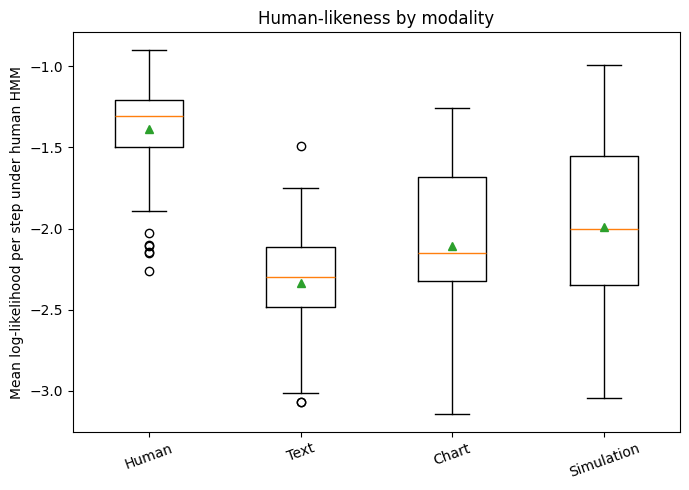

In [64]:
plt.figure(figsize=(7, 5))

data = [
    human_df["human_hmm_mean_loglik_per_step"],
    model_df[model_df["modality"] == "text"]["human_hmm_mean_loglik_per_step"],
    model_df[model_df["modality"] == "chart"]["human_hmm_mean_loglik_per_step"],
    model_df[model_df["modality"] == "simulation"]["human_hmm_mean_loglik_per_step"],
]

labels = ["Human", "Text", "Chart", "Simulation"]

plt.boxplot(data, labels=labels, showmeans=True)
plt.ylabel("Mean log-likelihood per step under human HMM")
plt.title("Human-likeness by modality")
plt.xticks(rotation=20)
plt.tight_layout()
plt.show()

C:\Users\14257\AppData\Local\Temp\ipykernel_94260\3415403436.py:10: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(data, labels=order, showmeans=True)


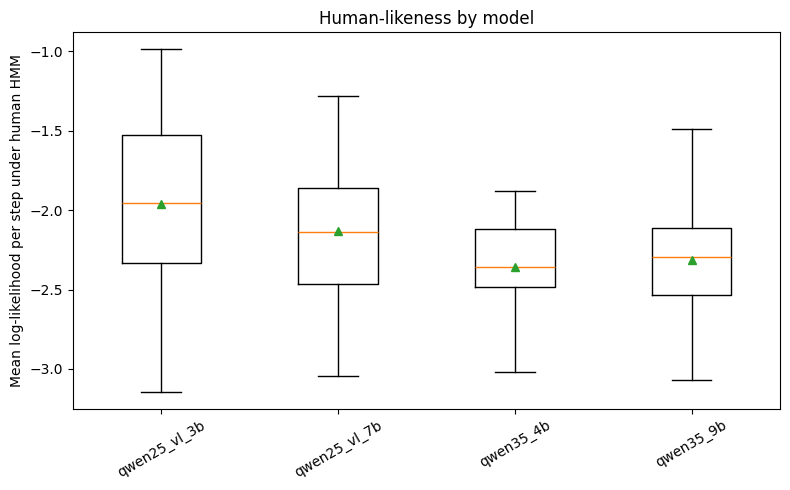

In [65]:
plt.figure(figsize=(8, 5))

order = sorted(model_df["model"].dropna().unique())

data = [
    model_df[model_df["model"] == m]["human_hmm_mean_loglik_per_step"]
    for m in order
]

plt.boxplot(data, labels=order, showmeans=True)
plt.ylabel("Mean log-likelihood per step under human HMM")
plt.title("Human-likeness by model")
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()

C:\Users\14257\AppData\Local\Temp\ipykernel_94260\4023169615.py:10: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(data, labels=labels, showmeans=True)


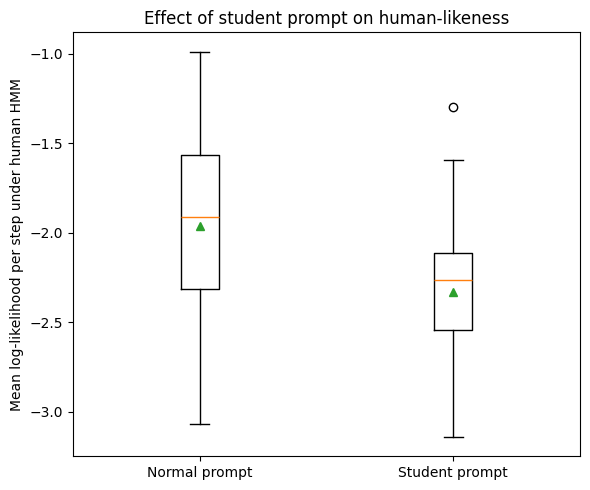

In [66]:
plt.figure(figsize=(6, 5))

data = [
    model_df[model_df["prompt_condition"] == "normal"]["human_hmm_mean_loglik_per_step"],
    model_df[model_df["prompt_condition"] == "student"]["human_hmm_mean_loglik_per_step"],
]

labels = ["Normal prompt", "Student prompt"]

plt.boxplot(data, labels=labels, showmeans=True)
plt.ylabel("Mean log-likelihood per step under human HMM")
plt.title("Effect of student prompt on human-likeness")
plt.tight_layout()
plt.show()

C:\Users\14257\AppData\Local\Temp\ipykernel_94260\1646318245.py:13: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(data, labels=labels, showmeans=True)


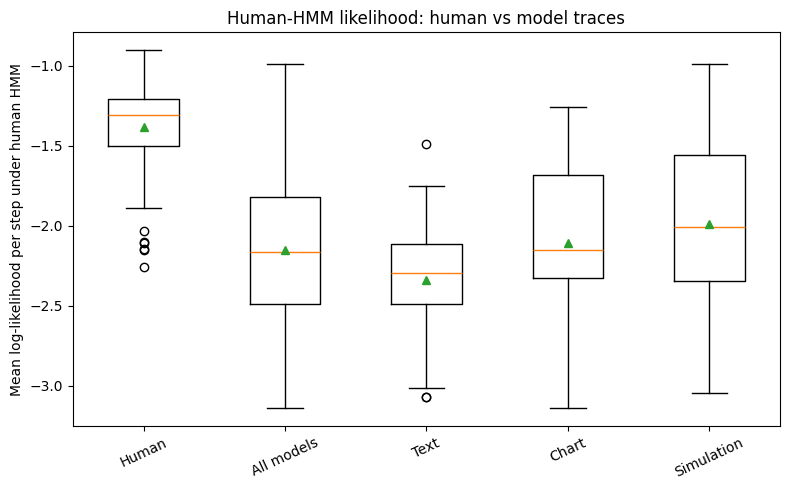

In [67]:
plt.figure(figsize=(8, 5))

data = [
    human_df["human_hmm_mean_loglik_per_step"],
    model_df["human_hmm_mean_loglik_per_step"],
    model_df[model_df["modality"] == "text"]["human_hmm_mean_loglik_per_step"],
    model_df[model_df["modality"] == "chart"]["human_hmm_mean_loglik_per_step"],
    model_df[model_df["modality"] == "simulation"]["human_hmm_mean_loglik_per_step"],
]

labels = ["Human", "All models", "Text", "Chart", "Simulation"]

plt.boxplot(data, labels=labels, showmeans=True)
plt.ylabel("Mean log-likelihood per step under human HMM")
plt.title("Human-HMM likelihood: human vs model traces")
plt.xticks(rotation=25)
plt.tight_layout()
plt.show()

In [68]:
emission_df = pd.read_csv(OUTPUT_DIR / "method1_hmm_emission_probabilities_metadata_fixed.csv")

human_emission = emission_df[emission_df["hmm_group"] == "human"].copy()

pivot = human_emission.pivot(
    index="state_id",
    columns="action",
    values="emission_prob"
)

display(pivot)

action,decrease_concentration,decrease_path_length,decrease_wavelength,finish,increase_concentration,increase_path_length,increase_wavelength
state_id,,,,,,,
0,0.003283,9.999930e-07,0.460868,0.014018,0.019392,0.002672,0.499766
1,0.000023,4.503294e-01,0.004731,0.023091,0.008200,0.499221,0.014405
2,0.415790,4.882688e-03,0.000859,0.011172,0.560924,0.004328,0.002046


<Figure size 1000x500 with 0 Axes>

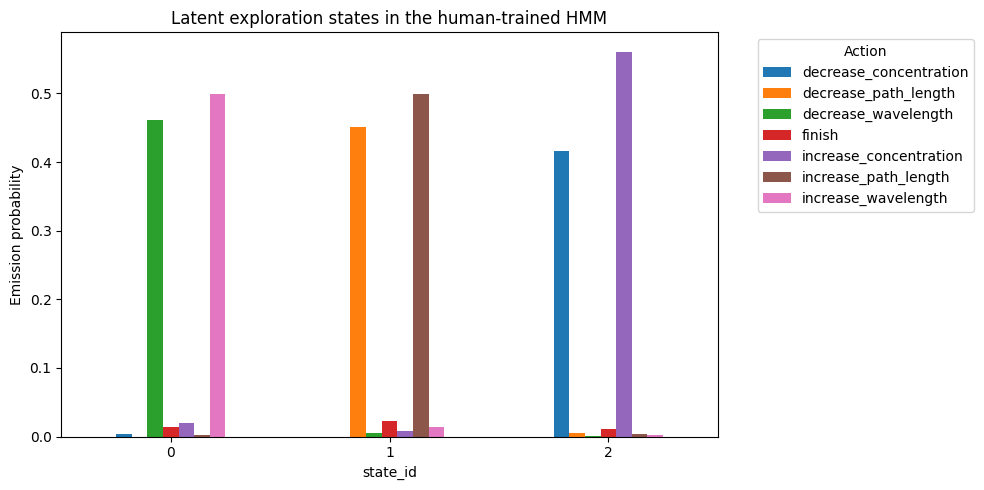

In [69]:
plt.figure(figsize=(10, 5))

pivot.plot(kind="bar", figsize=(10, 5))

plt.ylabel("Emission probability")
plt.title("Latent exploration states in the human-trained HMM")
plt.xticks(rotation=0)
plt.legend(title="Action", bbox_to_anchor=(1.05, 1), loc="upper left")
plt.tight_layout()
plt.show()

In [70]:
# Decode each trace using human HMM
decode_rows = []

human_hmm = hmm_models["human"]

for _, row in trace_df.iterrows():
    seq = row["encoded_sequence"]
    X = np.asarray(seq, dtype=int).reshape(-1, 1)

    logprob, states = human_hmm.decode(X, algorithm="viterbi")

    for t, state in enumerate(states):
        decode_rows.append({
            "episode_id": row["episode_id"],
            "source": row["source"],
            "modality": row["modality"],
            "prompt_condition": row["prompt_condition"],
            "model": row["model"],
            "hmm_group": row["hmm_group"],
            "step": t,
            "action": row["trace"][t],
            "decoded_state": state,
        })

decoded_state_df = pd.DataFrame(decode_rows)

display(decoded_state_df.head())

,episode_id,source,modality,prompt_condition,model,hmm_group,step,action,decoded_state
0,human__ex_bckp1-B-DC_sim1.pkl,human,human,human,human,human,0,increase_concentration,2
1,human__ex_bckp1-B-DC_sim1.pkl,human,human,human,human,human,1,decrease_concentration,2
2,human__ex_bckp1-B-DC_sim1.pkl,human,human,human,human,human,2,increase_concentration,2
3,human__ex_bckp1-B-DC_sim1.pkl,human,human,human,human,human,3,increase_concentration,2
4,human__ex_bckp1-B-DC_sim1.pkl,human,human,human,human,human,4,increase_concentration,2


decoded_state,0,1,2
modality,,,
chart,0.662687,0.092537,0.244776
human,0.397586,0.209217,0.393197
simulation,0.636816,0.151741,0.211443
text,0.469741,0.302594,0.227666


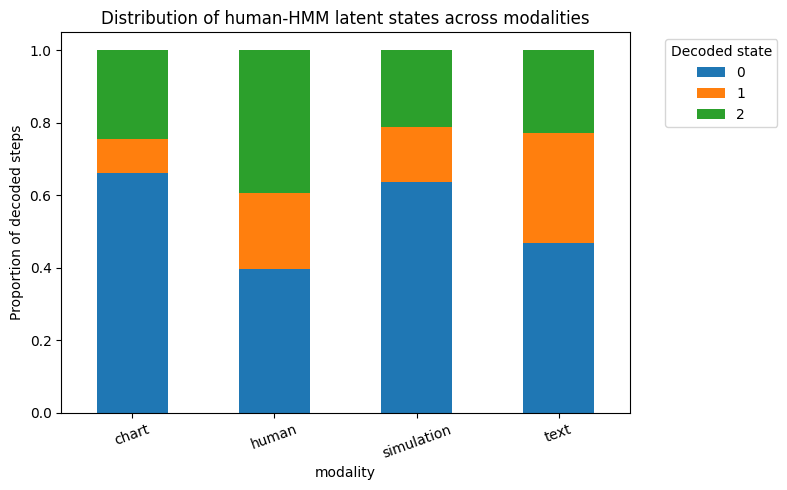

In [71]:
state_dist = (
    decoded_state_df
    .groupby(["source", "modality", "decoded_state"])
    .size()
    .reset_index(name="count")
)

state_dist["prop"] = state_dist.groupby(["source", "modality"])["count"].transform(
    lambda x: x / x.sum()
)

pivot_state = state_dist.pivot_table(
    index="modality",
    columns="decoded_state",
    values="prop",
    fill_value=0
)

display(pivot_state)

pivot_state.plot(kind="bar", stacked=True, figsize=(8, 5))

plt.ylabel("Proportion of decoded steps")
plt.title("Distribution of human-HMM latent states across modalities")
plt.xticks(rotation=20)
plt.legend(title="Decoded state", bbox_to_anchor=(1.05, 1), loc="upper left")
plt.tight_layout()
plt.show()

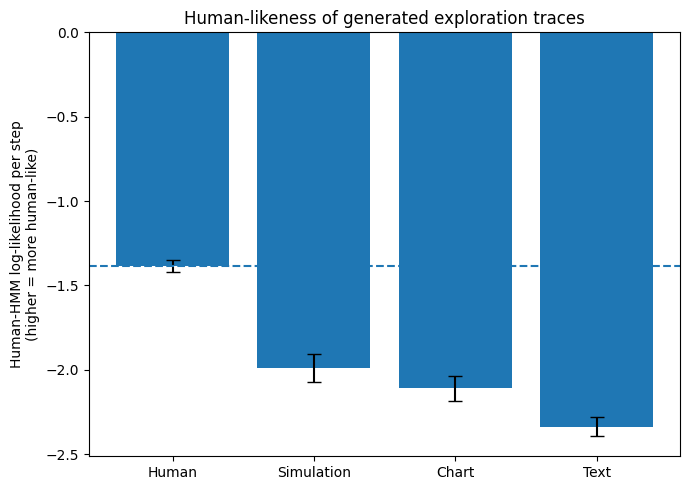

,group,mean,std,count,se
1,Human,-1.384511,0.302958,81,0.033662
2,Simulation,-1.988952,0.527356,38,0.085548
0,Chart,-2.109114,0.449582,38,0.072932
3,Text,-2.336626,0.355048,40,0.056138


In [72]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

summary = (
    score_df
    .assign(group=lambda d: np.where(d["source"] == "human", "Human", d["modality"].str.title()))
    .groupby("group")["human_hmm_mean_loglik_per_step"]
    .agg(["mean", "std", "count"])
    .reset_index()
)

summary["se"] = summary["std"] / np.sqrt(summary["count"])

order = ["Human", "Simulation", "Chart", "Text"]
summary["group"] = pd.Categorical(summary["group"], categories=order, ordered=True)
summary = summary.sort_values("group")

plt.figure(figsize=(7, 5))
plt.bar(summary["group"], summary["mean"], yerr=summary["se"], capsize=5)
plt.ylabel("Human-HMM log-likelihood per step\n(higher = more human-like)")
plt.title("Human-likeness of generated exploration traces")
plt.axhline(summary.loc[summary["group"] == "Human", "mean"].iloc[0], linestyle="--")
plt.tight_layout()
plt.show()

display(summary)

,modality,prompt_condition,mean,std,count,se
0,chart,normal,-1.945323,0.434775,19,0.099744
1,chart,student,-2.272906,0.412081,19,0.094538
2,simulation,normal,-1.628750,0.347799,19,0.079791
3,simulation,student,-2.349153,0.420462,19,0.096461
4,text,normal,-2.303126,0.431573,20,0.096503
5,text,student,-2.370125,0.264830,20,0.059218


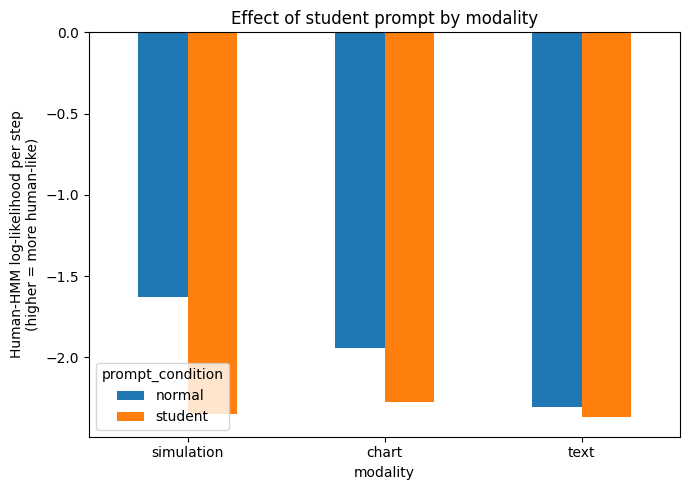

In [73]:
prompt_summary = (
    model_df
    .groupby(["modality", "prompt_condition"])["human_hmm_mean_loglik_per_step"]
    .agg(["mean", "std", "count"])
    .reset_index()
)

prompt_summary["se"] = prompt_summary["std"] / np.sqrt(prompt_summary["count"])

display(prompt_summary)

pivot = prompt_summary.pivot(index="modality", columns="prompt_condition", values="mean")
pivot = pivot.loc[["simulation", "chart", "text"]]

pivot.plot(kind="bar", figsize=(7, 5))

plt.ylabel("Human-HMM log-likelihood per step\n(higher = more human-like)")
plt.title("Effect of student prompt by modality")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

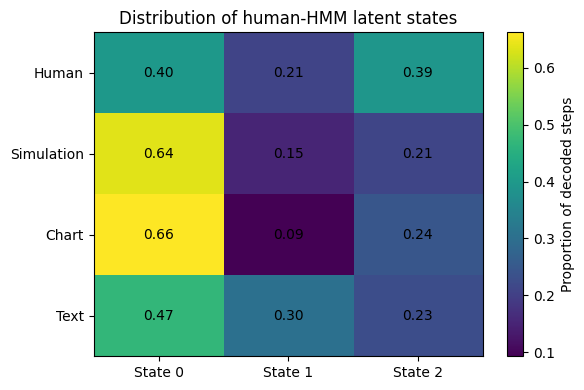

In [74]:
state_heat = pivot_state.copy()
state_heat = state_heat.loc[["human", "simulation", "chart", "text"]]

plt.figure(figsize=(6, 4))
plt.imshow(state_heat.values, aspect="auto")

plt.xticks(range(state_heat.shape[1]), [f"State {c}" for c in state_heat.columns])
plt.yticks(range(state_heat.shape[0]), [x.title() for x in state_heat.index])

for i in range(state_heat.shape[0]):
    for j in range(state_heat.shape[1]):
        plt.text(j, i, f"{state_heat.values[i, j]:.2f}", ha="center", va="center")

plt.colorbar(label="Proportion of decoded steps")
plt.title("Distribution of human-HMM latent states")
plt.tight_layout()
plt.show()

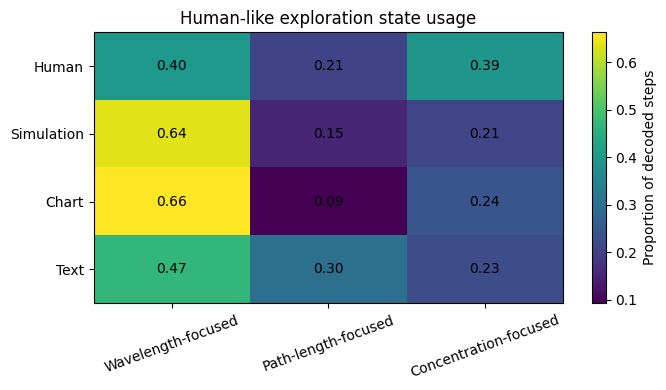

In [75]:
state_names = {
    0: "Wavelength-focused",
    1: "Path-length-focused",
    2: "Concentration-focused",
}

state_heat_named = state_heat.rename(columns=state_names)

plt.figure(figsize=(7, 4))
plt.imshow(state_heat_named.values, aspect="auto")

plt.xticks(range(state_heat_named.shape[1]), state_heat_named.columns, rotation=20)
plt.yticks(range(state_heat_named.shape[0]), [x.title() for x in state_heat_named.index])

for i in range(state_heat_named.shape[0]):
    for j in range(state_heat_named.shape[1]):
        plt.text(j, i, f"{state_heat_named.values[i, j]:.2f}", ha="center", va="center")

plt.colorbar(label="Proportion of decoded steps")
plt.title("Human-like exploration state usage")
plt.tight_layout()
plt.show()